# 04 — Aggregation & Geographic Analysis

Aggregate article-level stance scores to the newspaper level, merge with
geographic data (via LCCN lookup), and examine regional patterns in the
gold vs. silver debate.

**Input**: `data/results/newspaper_stances.parquet`  
**Output**: `data/results/newspaper_stances.parquet`

In [1]:
import sys
sys.path.insert(0, "..")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from src.geo_lookup import build_lccn_crosswalk, normalize_state

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [2]:
df = pd.read_parquet("../data/results/article_stances.parquet")
print(f"Articles with stance scores: {len(df):,}")
print(f"Unique newspapers (by name): {df['newspaper_name'].nunique()}")
print(f"Unique LCCNs: {df['lccn'].nunique()}")

Articles with stance scores: 56,355
Unique newspapers (by name): 298
Unique LCCNs: 299


## Step 1: Geographic Lookup via LCCN

Two-stage approach: first extract state from newspaper names (instant),
then fall back to the loc.gov API for any that can't be resolved. API
results are cached so you only pay the cost once.

In [3]:
unique_lccns = df['lccn'].dropna().unique().tolist()
unique_lccns = [l for l in unique_lccns if l]  # drop empty strings
print(f"Unique LCCNs to look up: {len(unique_lccns)}")

# Build LCCN -> newspaper_name mapping for name-based extraction
lccn_to_name = df.groupby('lccn')['newspaper_name'].first().to_dict()

geo_df = build_lccn_crosswalk(
    lccns=unique_lccns,
    newspaper_names=lccn_to_name,
    cache_path="../data/lccn_metadata/lccn_cache.json",
    rate_limit_seconds=8.0,
    use_api=True,  # Set to True once loc.gov rate limit resets
)

print(f"\nGeographic data retrieved for {len(geo_df)} LCCNs")
print(f"States found: {geo_df['state_full'].nunique()}")

# Show breakdown by source
if 'source' in geo_df.columns:
    print(f"\nResolution source:")
    print(geo_df['source'].value_counts())

geo_df.head()

Unique LCCNs to look up: 298
Loaded 298 cached LCCN lookups.
Resolved 0 LCCNs from newspaper names.
Saved 298 LCCN lookups to cache.

Geographic coverage: 298/298 LCCNs have state info.

Geographic data retrieved for 298 LCCNs
States found: 37

Resolution source:
source
loc_gov_api        244
name_extraction     54
Name: count, dtype: int64


,lccn,title,place_of_publication,city,state,start_year,end_year,publisher,source,state_full
0,sn84027718,Connecticut western news.,Connecticut,,connecticut,,,,name_extraction,Connecticut
1,sn85032938,Arizona weekly journal-miner.,Arizona,,arizona,,,,name_extraction,Arizona
2,sn84025968,Los Angeles herald.,"Los Angeles, California",Los Angeles,california,,,,name_extraction,California
3,sn86063206,"The Delta Independent (Delta, Colo.) 1886-19??","Delta, Colorado",delta,colorado,1886,,,loc_gov_api,Colorado
4,sn84024828,"Mohave County Miner (Mineral Park, A.T. [Ariz....","Mineral Park, Arizona",mineral park,arizona,1882,,"Smith, Anson H.",loc_gov_api,Arizona


In [4]:
# Check coverage
print("State distribution:")
print(geo_df['state_full'].value_counts().head(20))

State distribution:
state_full
Minnesota               26
Kansas                  22
Arizona                 21
Mississippi             20
Maryland                14
Arkansas                13
Montana                 13
Missouri                12
New Mexico              12
North Carolina          11
Louisiana               11
Kentucky                10
District Of Columbia     9
Michigan                 9
Delaware                 9
New Jersey               9
Connecticut              8
Colorado                 8
North Dakota             8
California               7
Name: count, dtype: int64


## Step 2: Aggregate to Newspaper Level

In [5]:
# Aggregate by newspaper (LCCN)
newspaper_agg = df.groupby('lccn').agg(
    newspaper_name=('newspaper_name', 'first'),
    n_articles=('article', 'count'),
    mean_pro_gold=('pro_gold_score', 'mean'),
    mean_pro_silver=('pro_silver_score', 'mean'),
    median_pro_gold=('pro_gold_score', 'median'),
    median_pro_silver=('pro_silver_score', 'median'),
    std_pro_gold=('pro_gold_score', 'std'),
    std_pro_silver=('pro_silver_score', 'std'),
).reset_index()

# Compute a net stance measure: positive = more pro-gold, negative = more pro-silver
newspaper_agg['net_gold_silver'] = (
    newspaper_agg['mean_pro_gold'] - newspaper_agg['mean_pro_silver']
)

print(f"Newspapers with aggregated stances: {len(newspaper_agg):,}")
newspaper_agg.head()

Newspapers with aggregated stances: 299


,lccn,newspaper_name,n_articles,mean_pro_gold,mean_pro_silver,median_pro_gold,median_pro_silver,std_pro_gold,std_pro_silver,net_gold_silver
0,,The American.,82,9.604176e-02,1.782251e-01,1.756808e-06,8.410916e-07,0.287857,0.377840,-8.218332e-02
1,sn2004060008,Safford rattler.,1,1.286100e-07,1.385170e-07,1.286100e-07,1.385170e-07,NaN,NaN,-9.907041e-09
2,sn2008058169,The Washington critic.,15,2.644202e-05,7.268832e-02,9.093305e-07,5.089637e-07,0.000094,0.257352,-7.266188e-02
3,sn2008058170,The daily critic.,30,3.334085e-02,2.376908e-01,5.714445e-07,1.380822e-05,0.182326,0.425926,-2.043500e-01
4,sn2008058171,The critic.,34,2.940360e-02,2.053865e-01,1.458704e-06,2.226101e-06,0.171346,0.409251,-1.759829e-01


In [6]:
# Merge with geographic data
newspaper_geo = newspaper_agg.merge(
    geo_df[['lccn', 'city', 'state', 'state_full', 'place_of_publication']],
    on='lccn',
    how='left',
)

print(f"Newspapers with geographic data: {newspaper_geo['state_full'].notna().sum()}")
print(f"Missing geographic data: {newspaper_geo['state_full'].isna().sum()}")

Newspapers with geographic data: 298
Missing geographic data: 1


## Validation: Stance Scores by Keyword

If the stance detector is working, articles containing inherently pro-silver
terms (e.g. "silverites", "free silver", "free coinage") should score higher
on the pro-silver classifier, and articles with pro-gold terms (e.g. "sound money",
"gold standard", "gold bugs") should score higher on pro-gold.

In [7]:
# Define stance-laden keyword groups
pro_silver_terms = ["silverites", "silverite", "free silver", "free coinage",
                    "coinage of silver", "silver coinage", "sixteen to one", "16 to 1"]
pro_gold_terms = ["gold bugs", "gold bug", "goldbugs", "sound money", "honest money",
                  "gold standard", "gold coinage", "coinage of gold"]
neutral_terms = ["bimetallism", "bimetallic", "monetary standard", "currency question",
                 "sherman silver", "bland-allison", "bland allison"]

# Parse matched_keywords: always convert to lists
kw_lists = df['matched_keywords'].apply(
    lambda x: x.split('|') if isinstance(x, str) else (x if isinstance(x, list) else [])
)

print(f"Sample parsed keywords: {kw_lists.iloc[:3].tolist()}")

def has_any_term(kw_list, terms):
    """Check if any term in `terms` appears in the keyword list."""
    return any(t in kw_list for t in terms)

# Tag each article
df['has_pro_silver_term'] = kw_lists.apply(lambda x: has_any_term(x, pro_silver_terms))
df['has_pro_gold_term'] = kw_lists.apply(lambda x: has_any_term(x, pro_gold_terms))
df['has_neutral_term'] = kw_lists.apply(lambda x: has_any_term(x, neutral_terms))

print(f"\nArticles with pro-silver terms: {df['has_pro_silver_term'].sum()}")
print(f"Articles with pro-gold terms: {df['has_pro_gold_term'].sum()}")
print(f"Articles with neutral terms: {df['has_neutral_term'].sum()}")

# Compute mean scores by keyword group
groups = {
    'Articles with pro-silver terms': df[df['has_pro_silver_term']],
    'Articles with pro-gold terms': df[df['has_pro_gold_term']],
    'Articles with neutral terms only': df[df['has_neutral_term'] & ~df['has_pro_silver_term'] & ~df['has_pro_gold_term']],
    'All articles': df,
}

print(f"\n{'Group':<40s}  {'N':>5s}  {'Pro-Gold':>10s}  {'Pro-Silver':>10s}  {'Net':>10s}")
print("-" * 82)
for label, subset in groups.items():
    if len(subset) > 0:
        pg = subset['pro_gold_score'].mean()
        ps = subset['pro_silver_score'].mean()
        print(f"{label:<40s}  {len(subset):>5d}  {pg:>10.4f}  {ps:>10.4f}  {pg - ps:>10.4f}")
    else:
        print(f"{label:<40s}  {'--':>5s}  {'--':>10s}  {'--':>10s}  {'--':>10s}")

Sample parsed keywords: [['silver coinage', 'free coinage'], ['free coinage'], ['coinage of silver']]

Articles with pro-silver terms: 37948
Articles with pro-gold terms: 23277
Articles with neutral terms: 7469

Group                                         N    Pro-Gold  Pro-Silver         Net
----------------------------------------------------------------------------------
Articles with pro-silver terms            37948      0.1053      0.2834     -0.1781
Articles with pro-gold terms              23277      0.1957      0.2521     -0.0564
Articles with neutral terms only           3458      0.0799      0.1949     -0.1151
All articles                              56355      0.1260      0.2653     -0.1394


Found scores for 23 keywords


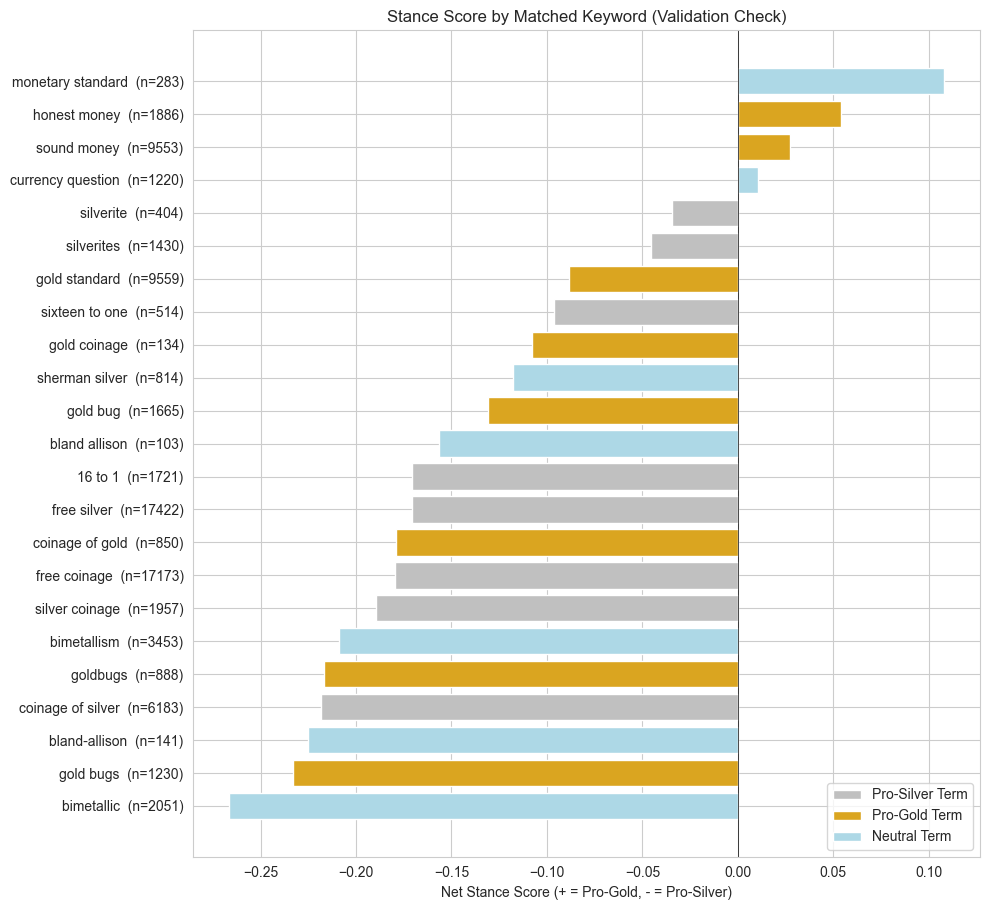

In [8]:
# Per-keyword breakdown: mean stance scores for individual terms
all_terms = pro_silver_terms + pro_gold_terms + neutral_terms
rows = []

for term in all_terms:
    mask = kw_lists.apply(lambda x, t=term: t in x)
    n = mask.sum()
    if n > 0:
        pg = df.loc[mask, 'pro_gold_score'].mean()
        ps = df.loc[mask, 'pro_silver_score'].mean()
        if term in pro_silver_terms:
            group = "Pro-Silver Term"
        elif term in pro_gold_terms:
            group = "Pro-Gold Term"
        else:
            group = "Neutral Term"
        rows.append({"keyword": term, "n": n, "pro_gold": pg,
                      "pro_silver": ps, "net": pg - ps, "group": group})

print(f"Found scores for {len(rows)} keywords")

if rows:
    kw_scores = pd.DataFrame(rows).sort_values("net", ascending=True)

    fig, ax = plt.subplots(figsize=(10, max(6, len(kw_scores) * 0.4)))
    colors = {"Pro-Silver Term": "silver", "Pro-Gold Term": "goldenrod", "Neutral Term": "lightblue"}
    bar_colors = [colors[g] for g in kw_scores['group']]

    ax.barh(range(len(kw_scores)), kw_scores['net'], color=bar_colors)
    ax.set_yticks(range(len(kw_scores)))
    ax.set_yticklabels([f"{row['keyword']}  (n={row['n']})" for _, row in kw_scores.iterrows()])
    ax.set_xlabel('Net Stance Score (+ = Pro-Gold, - = Pro-Silver)')
    ax.set_title('Stance Score by Matched Keyword (Validation Check)')
    ax.axvline(0, color='black', linewidth=0.5)

    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor=c, label=g) for g, c in colors.items()]
    ax.legend(handles=legend_elements, loc='lower right')
    plt.tight_layout()
    plt.show()
else:
    print("No keyword matches found. Check kw_lists parsing above.")

## Step 3: Regional Analysis

The key hypothesis: newspapers in the South and West should lean pro-silver,
while those in the Northeast should lean pro-gold.

In [9]:
# Define regions (following conventional Census regions)
REGIONS = {
    'Northeast': ['Connecticut', 'Maine', 'Massachusetts', 'New Hampshire',
                  'Rhode Island', 'Vermont', 'New Jersey', 'New York',
                  'Pennsylvania'],
    'Midwest': ['Illinois', 'Indiana', 'Iowa', 'Kansas', 'Michigan',
                'Minnesota', 'Missouri', 'Nebraska', 'North Dakota',
                'Ohio', 'South Dakota', 'Wisconsin'],
    'South': ['Alabama', 'Arkansas', 'Delaware', 'Florida', 'Georgia',
              'Kentucky', 'Louisiana', 'Maryland', 'Mississippi',
              'North Carolina', 'Oklahoma', 'South Carolina', 'Tennessee',
              'Texas', 'Virginia', 'West Virginia',
              'District of Columbia'],
    'West': ['Alaska', 'Arizona', 'California', 'Colorado', 'Hawaii',
             'Idaho', 'Montana', 'Nevada', 'New Mexico', 'Oregon',
             'Utah', 'Washington', 'Wyoming'],
}

state_to_region = {}
for region, states in REGIONS.items():
    for state in states:
        state_to_region[state] = region

newspaper_geo['region'] = newspaper_geo['state_full'].map(state_to_region)
print("Newspapers by region:")
print(newspaper_geo['region'].value_counts())

Newspapers by region:
region
South        98
Midwest      96
West         70
Northeast    25
Name: count, dtype: int64


In [10]:
# Filter to newspapers with enough articles for stable estimates
MIN_ARTICLES = 5
newspaper_stable = newspaper_geo[newspaper_geo['n_articles'] >= MIN_ARTICLES].copy()
print(f"Newspapers with >= {MIN_ARTICLES} articles: {len(newspaper_stable)}")

Newspapers with >= 5 articles: 232


In [11]:
# Regional comparison: mean stance scores
regional_summary = newspaper_stable.groupby('region').agg(
    n_newspapers=('lccn', 'count'),
    mean_pro_gold=('mean_pro_gold', 'mean'),
    mean_pro_silver=('mean_pro_silver', 'mean'),
    mean_net_gold_silver=('net_gold_silver', 'mean'),
).round(4)

print("Regional Stance Summary:")
print(regional_summary)

Regional Stance Summary:
           n_newspapers  mean_pro_gold  mean_pro_silver  mean_net_gold_silver
region                                                                       
Midwest              76         0.1031           0.2571               -0.1541
Northeast            19         0.1556           0.1683               -0.0127
South                72         0.1121           0.2509               -0.1388
West                 57         0.0745           0.3623               -0.2877


Saved to ../figures/regional_boxplots.png


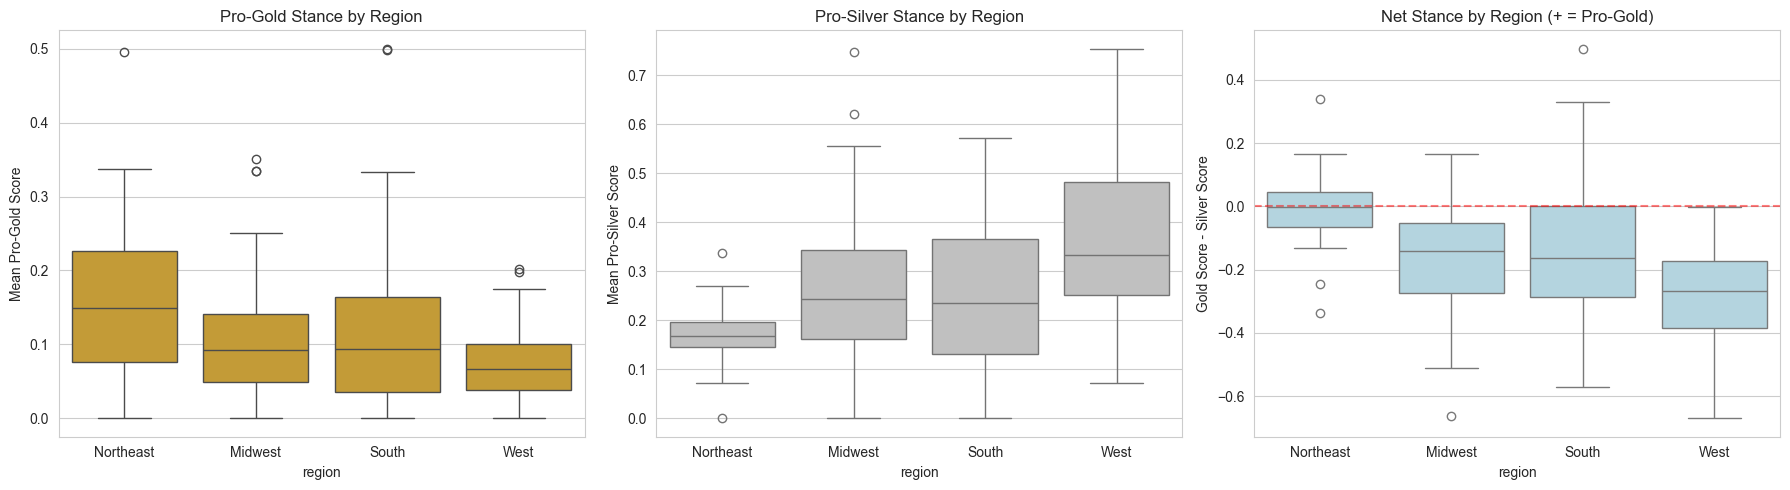

In [12]:
# Visualize regional differences
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Pro-gold by region
region_order = ['Northeast', 'Midwest', 'South', 'West']
valid_regions = newspaper_stable.dropna(subset=['region'])

sns.boxplot(data=valid_regions, x='region', y='mean_pro_gold',
            order=region_order, ax=axes[0], color='goldenrod')
axes[0].set_title('Pro-Gold Stance by Region')
axes[0].set_ylabel('Mean Pro-Gold Score')

# Pro-silver by region
sns.boxplot(data=valid_regions, x='region', y='mean_pro_silver',
            order=region_order, ax=axes[1], color='silver')
axes[1].set_title('Pro-Silver Stance by Region')
axes[1].set_ylabel('Mean Pro-Silver Score')

# Net stance by region
sns.boxplot(data=valid_regions, x='region', y='net_gold_silver',
            order=region_order, ax=axes[2], color='lightblue')
axes[2].set_title('Net Stance by Region (+ = Pro-Gold)')
axes[2].set_ylabel('Gold Score - Silver Score')
axes[2].axhline(0, color='red', linestyle='--', alpha=0.5)

plt.tight_layout()

# Save for README
import os
os.makedirs("../figures", exist_ok=True)
fig.savefig("../figures/regional_boxplots.png", dpi=150, bbox_inches='tight', facecolor='white')
print("Saved to ../figures/regional_boxplots.png")
plt.show()

## Step 4: State-Level Analysis

In [13]:
# State-level aggregation
state_summary = newspaper_stable.groupby('state_full').agg(
    n_newspapers=('lccn', 'count'),
    mean_pro_gold=('mean_pro_gold', 'mean'),
    mean_pro_silver=('mean_pro_silver', 'mean'),
    mean_net=('net_gold_silver', 'mean'),
    region=('region', 'first'),
).sort_values('mean_net', ascending=False)

print("State-level stance summary (sorted by net pro-gold):")
print(state_summary.to_string())

State-level stance summary (sorted by net pro-gold):
                      n_newspapers  mean_pro_gold  mean_pro_silver  mean_net     region
state_full                                                                             
Ohio                             1       0.200032         0.137036  0.062997    Midwest
Iowa                             1       0.099970         0.044969  0.055001    Midwest
Maine                            4       0.162583         0.130726  0.031857  Northeast
New Jersey                       6       0.191728         0.168618  0.023110  Northeast
Nebraska                         3       0.133118         0.135949 -0.002831    Midwest
Maryland                        11       0.114894         0.135657 -0.020763      South
New York                         3       0.148750         0.172410 -0.023660  Northeast
North Dakota                     5       0.087104         0.113849 -0.026745    Midwest
Oregon                           1       0.151050         0.188124 

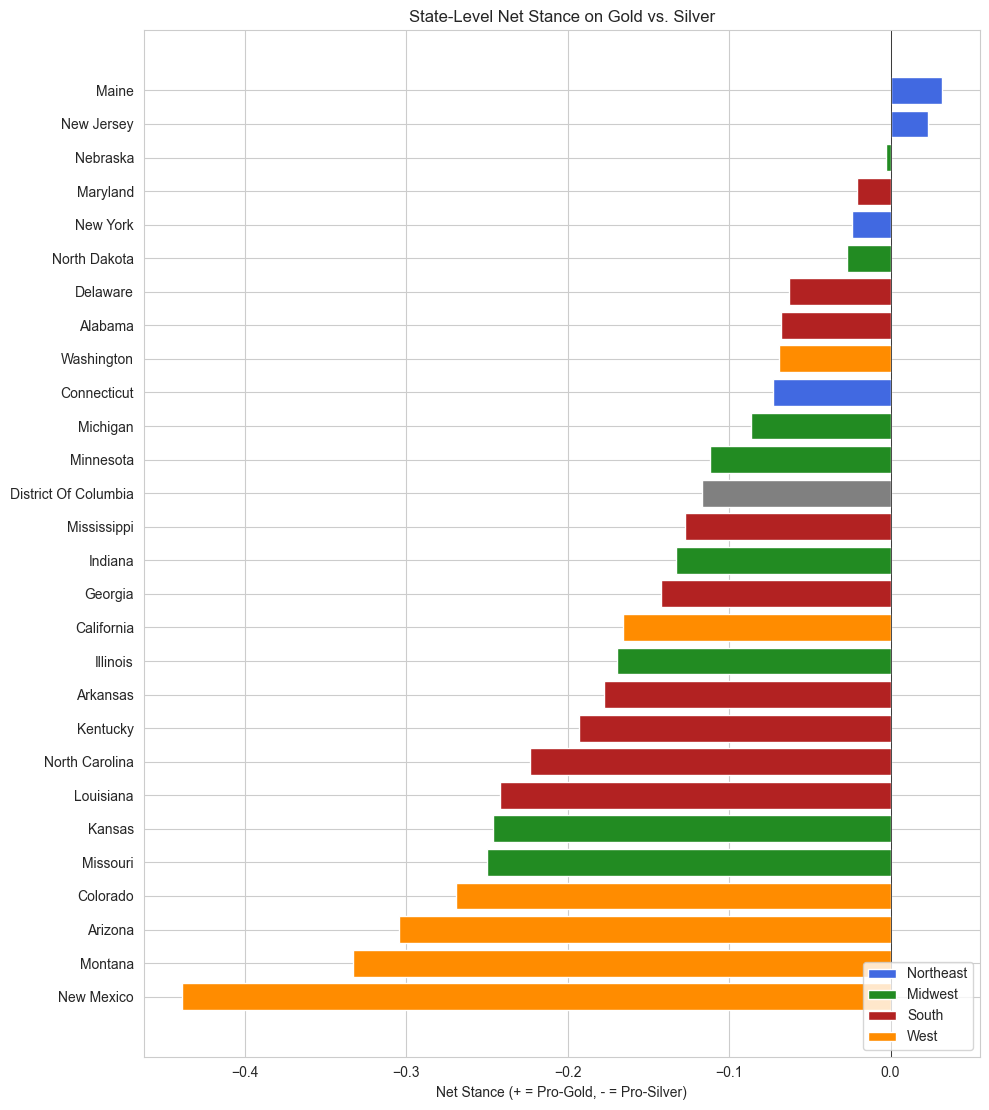

In [14]:
# Horizontal bar chart of states by net stance
# Only show states with >= 2 newspapers
state_plot = state_summary[state_summary['n_newspapers'] >= 2].copy()

if len(state_plot) > 0:
    # Color by region
    region_colors = {
        'Northeast': 'royalblue',
        'Midwest': 'forestgreen',
        'South': 'firebrick',
        'West': 'darkorange',
    }
    colors = [region_colors.get(r, 'gray') for r in state_plot['region']]
    
    fig, ax = plt.subplots(figsize=(10, max(6, len(state_plot) * 0.4)))
    ax.barh(range(len(state_plot)), state_plot['mean_net'], color=colors)
    ax.set_yticks(range(len(state_plot)))
    ax.set_yticklabels(state_plot.index)
    ax.set_xlabel('Net Stance (+ = Pro-Gold, - = Pro-Silver)')
    ax.set_title('State-Level Net Stance on Gold vs. Silver')
    ax.axvline(0, color='black', linewidth=0.5)
    ax.invert_yaxis()
    
    # Legend
    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor=c, label=r) for r, c in region_colors.items()]
    ax.legend(handles=legend_elements, loc='lower right')
    
    plt.tight_layout()
    plt.show()

### Choropleth Map: Net Stance by State

A geographic view of the same data, scaled to the actual range of values in the
data so that variation across states is visible. Bluer states lean more pro-gold
(or less pro-silver); redder states lean more strongly pro-silver. Gray states
have no data.

Saved interactive map to ../figures/stance_choropleth.html
Color range: -0.439 (most pro-silver) to 0.063 (most pro-gold)
Saved static map to ../figures/stance_choropleth.png


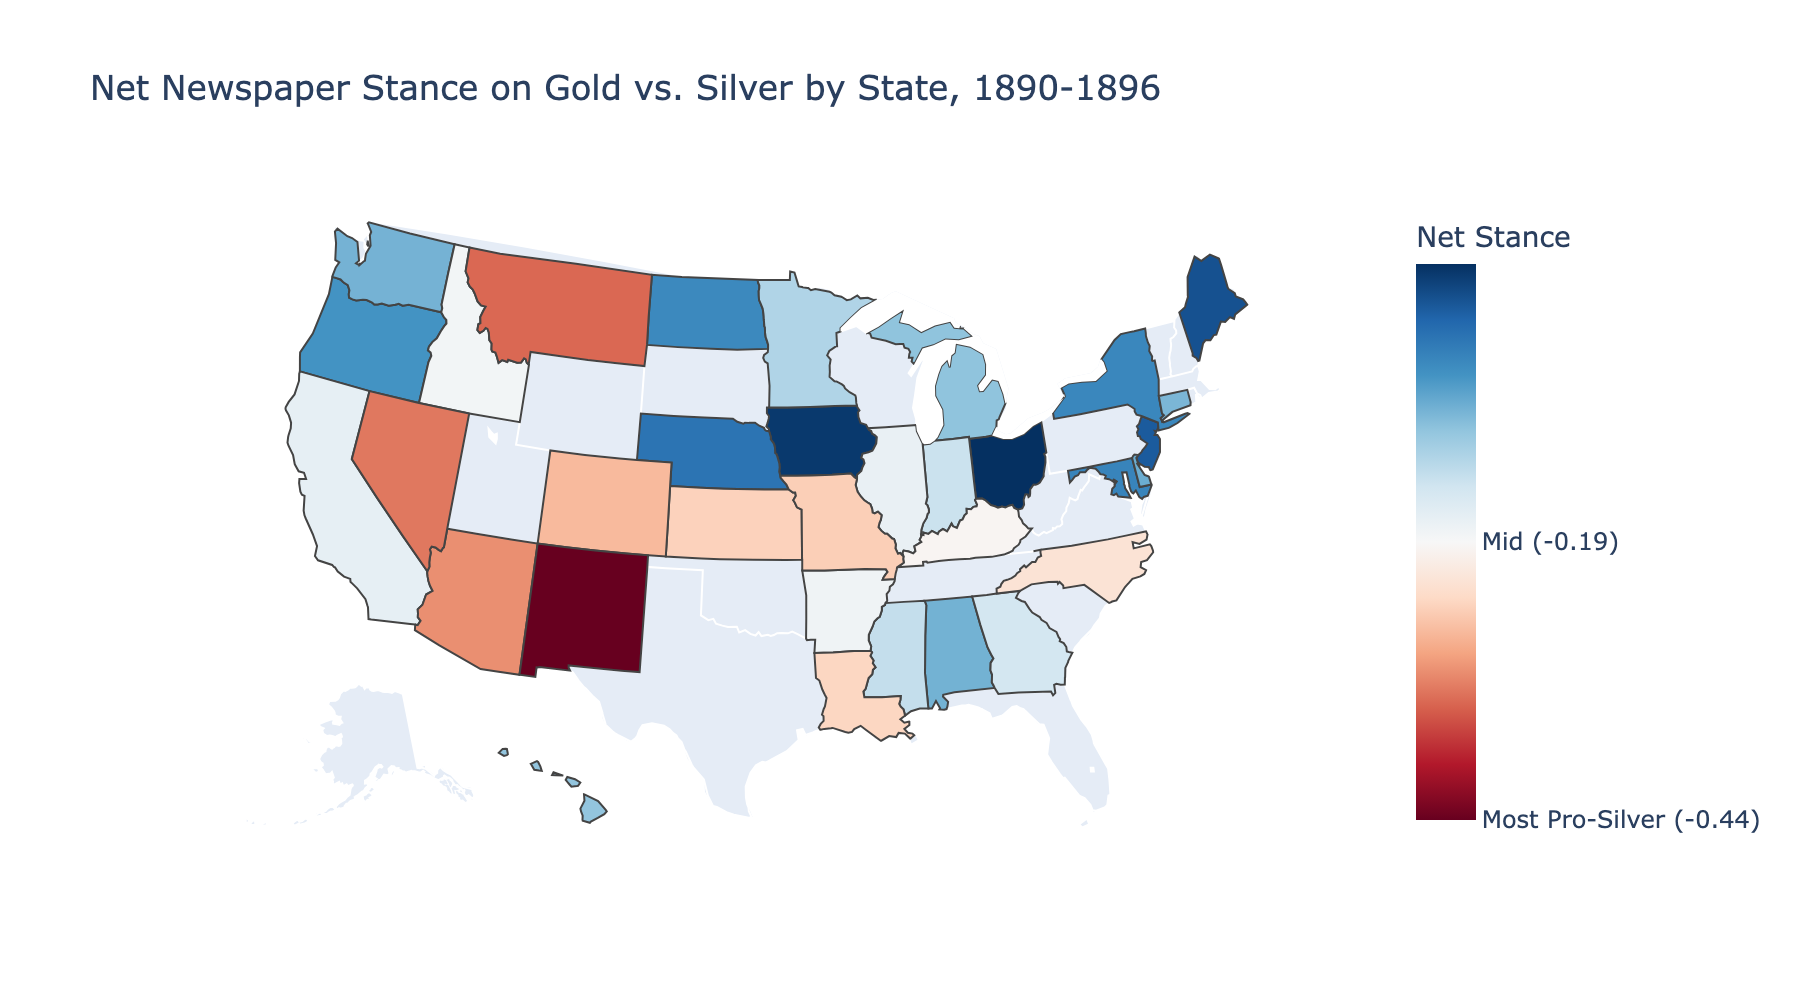

In [15]:
import plotly.express as px
import plotly.io as pio

# State name -> two-letter abbreviation for plotly
STATE_ABBREV = {
    'Alabama': 'AL', 'Alaska': 'AK', 'Arizona': 'AZ', 'Arkansas': 'AR',
    'California': 'CA', 'Colorado': 'CO', 'Connecticut': 'CT', 'Delaware': 'DE',
    'Florida': 'FL', 'Georgia': 'GA', 'Hawaii': 'HI', 'Idaho': 'ID',
    'Illinois': 'IL', 'Indiana': 'IN', 'Iowa': 'IA', 'Kansas': 'KS',
    'Kentucky': 'KY', 'Louisiana': 'LA', 'Maine': 'ME', 'Maryland': 'MD',
    'Massachusetts': 'MA', 'Michigan': 'MI', 'Minnesota': 'MN',
    'Mississippi': 'MS', 'Missouri': 'MO', 'Montana': 'MT', 'Nebraska': 'NE',
    'Nevada': 'NV', 'New Hampshire': 'NH', 'New Jersey': 'NJ',
    'New Mexico': 'NM', 'New York': 'NY', 'North Carolina': 'NC',
    'North Dakota': 'ND', 'Ohio': 'OH', 'Oklahoma': 'OK', 'Oregon': 'OR',
    'Pennsylvania': 'PA', 'Rhode Island': 'RI', 'South Carolina': 'SC',
    'South Dakota': 'SD', 'Tennessee': 'TN', 'Texas': 'TX', 'Utah': 'UT',
    'Vermont': 'VT', 'Virginia': 'VA', 'Washington': 'WA',
    'West Virginia': 'WV', 'Wisconsin': 'WI', 'Wyoming': 'WY',
    'District Of Columbia': 'DC',
}

# Prepare state data for choropleth
state_map = state_summary.copy()
state_map['state_abbrev'] = state_map.index.map(STATE_ABBREV)
state_map = state_map.dropna(subset=['state_abbrev'])

# Use the actual data range so that color variation shows the full spread,
# rather than a symmetric scale that compresses the pro-gold end.
vmin = state_map['mean_net'].min()
vmax = state_map['mean_net'].max()

fig_map = px.choropleth(
    state_map,
    locations='state_abbrev',
    locationmode='USA-states',
    color='mean_net',
    color_continuous_scale='RdBu',  # Red = pro-silver, Blue = pro-gold
    range_color=[vmin, vmax],
    scope='usa',
    hover_name=state_map.index,
    hover_data={
        'state_abbrev': False,
        'mean_net': ':.3f',
        'mean_pro_gold': ':.3f',
        'mean_pro_silver': ':.3f',
        'n_newspapers': True,
    },
    labels={
        'mean_net': 'Net Stance (+=Gold)',
        'mean_pro_gold': 'Pro-Gold',
        'mean_pro_silver': 'Pro-Silver',
        'n_newspapers': 'Newspapers',
    },
    title='Net Newspaper Stance on Gold vs. Silver by State, 1890-1896',
)

# Build readable tick labels spanning the actual data range
mid = (vmin + vmax) / 2
fig_map.update_layout(
    coloraxis_colorbar=dict(
        title='Net Stance',
        tickvals=[vmin, (vmin + mid) / 2, mid, (mid + vmax) / 2, vmax+0.1],
        ticktext=[
            f'Most Pro-Silver ({vmin:.2f})',
            '',
            f'Mid ({mid:.2f})',
            '',
            f'Most Pro-Gold ({vmax:.2f})',
        ],
    ),
    geo=dict(bgcolor='rgba(0,0,0,0)'),
    width=900,
    height=500,
)

# Save interactive HTML version
html_path = "../figures/stance_choropleth.html"
fig_map.write_html(html_path)
print(f"Saved interactive map to {html_path}")
print(f"Color range: {vmin:.3f} (most pro-silver) to {vmax:.3f} (most pro-gold)")

# Try to save static PNG (requires kaleido: pip install -U kaleido)
png_path = "../figures/stance_choropleth.png"
try:
    fig_map.write_image(png_path, scale=2)
    print(f"Saved static map to {png_path}")
    from IPython.display import Image, display
    display(Image(filename=png_path))
except Exception as e:
    print(f"Could not save static PNG ({e})")
    print("Install kaleido for static export: pip install -U kaleido")
    # Fall back to displaying via iframe
    try:
        from IPython.display import IFrame, display
        display(IFrame(src="../figures/stance_choropleth.html", width=920, height=520))
    except Exception:
        print(f"Open the interactive map directly: {html_path}")

## Step 5: Time Trends

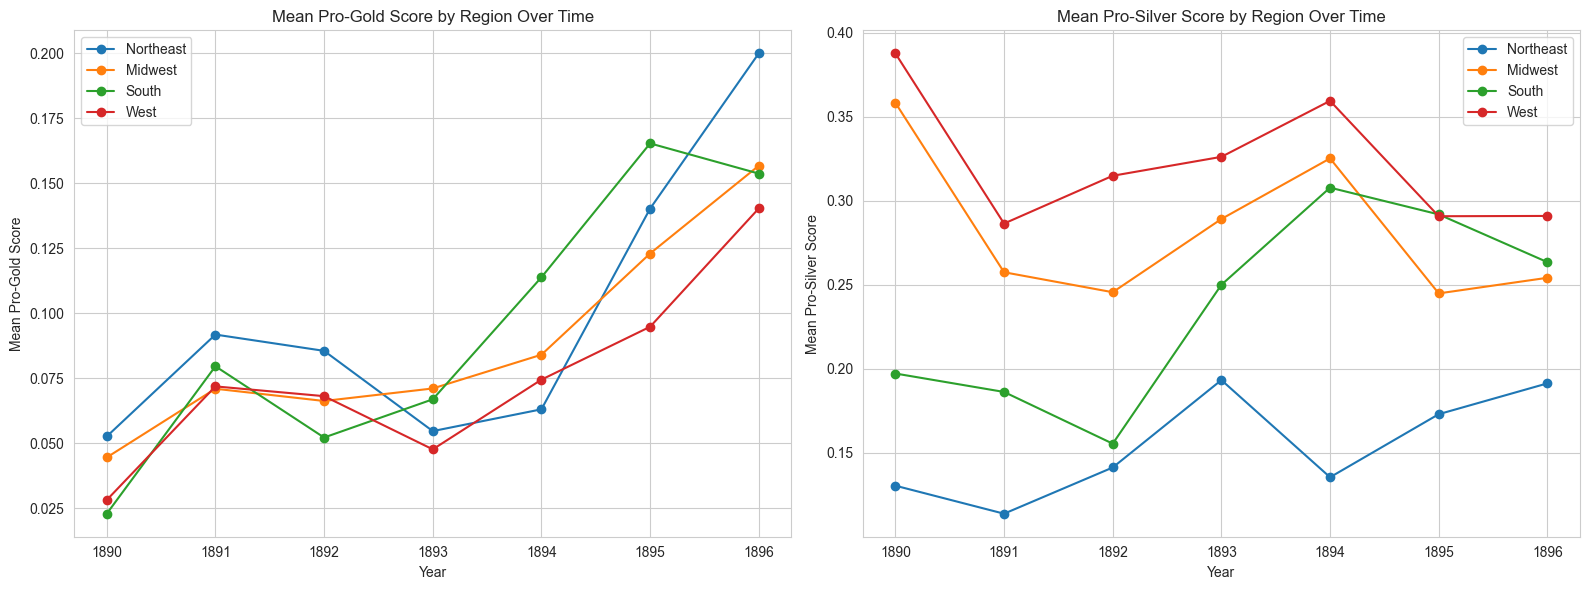

In [16]:
# Merge region info back to article-level data
df_with_geo = df.merge(
    geo_df[['lccn', 'state_full']],
    on='lccn',
    how='left',
)
df_with_geo['region'] = df_with_geo['state_full'].map(state_to_region)

# Convert year to integer for proper chronological ordering
df_with_geo['year_int'] = df_with_geo['year'].astype(int)

# Yearly stance by region
yearly_regional = df_with_geo.groupby(['year_int', 'region']).agg(
    mean_pro_gold=('pro_gold_score', 'mean'),
    mean_pro_silver=('pro_silver_score', 'mean'),
    n_articles=('article', 'count'),
).reset_index().sort_values('year_int')

# Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for region in region_order:
    subset = yearly_regional[yearly_regional['region'] == region]
    if len(subset) > 0:
        axes[0].plot(subset['year_int'], subset['mean_pro_gold'],
                     marker='o', label=region)
        axes[1].plot(subset['year_int'], subset['mean_pro_silver'],
                     marker='o', label=region)

for ax in axes:
    ax.set_xticks(range(1890, 1897))
    ax.set_xlabel('Year')

axes[0].set_title('Mean Pro-Gold Score by Region Over Time')
axes[0].set_ylabel('Mean Pro-Gold Score')
axes[0].legend()

axes[1].set_title('Mean Pro-Silver Score by Region Over Time')
axes[1].set_ylabel('Mean Pro-Silver Score')
axes[1].legend()

plt.tight_layout()
plt.show()

## Save Final Results

In [17]:
# Save newspaper-level results
SAVE_PATH = "../data/results/newspaper_stances.parquet"
newspaper_geo.to_parquet(SAVE_PATH, index=False)
print(f"Saved newspaper-level stances to {SAVE_PATH}")
print(f"  {len(newspaper_geo)} newspapers")
print(f"  Columns: {list(newspaper_geo.columns)}")

Saved newspaper-level stances to ../data/results/newspaper_stances.parquet
  299 newspapers
  Columns: ['lccn', 'newspaper_name', 'n_articles', 'mean_pro_gold', 'mean_pro_silver', 'median_pro_gold', 'median_pro_silver', 'std_pro_gold', 'std_pro_silver', 'net_gold_silver', 'city', 'state', 'state_full', 'place_of_publication', 'region']


In [18]:
# Also save state-level summary as CSV for easy inspection
state_summary.to_csv("../data/results/state_summary.csv")
print("Saved state-level summary to data/results/state_summary.csv")

Saved state-level summary to data/results/state_summary.csv
